# PhonePe Digital Payments Case Study

# NAME : THANNIRU DHARMA NITHIN
# REGISTERED E-MAIL :thannirudharmanithin2003@gmail.com

## Course
Data Analytics – Coding NinjaS

## Dataset : phonepe-pulse_raw-data.xlsx

## Objective

The objective of this case study is to analyze PhonePe transaction data along with demographic information across various states and districts in India.

The analysis aims to:

• Understand transaction trends across states and years  
• Identify device usage patterns among users  
• Explore relationships between population demographics and transaction activity  
• Perform data quality validation between district and state level datasets  
• Generate insights using statistical analysis and visualizations

---

## Dataset Overview

The dataset contains multiple sheets covering transaction statistics, user behavior, device usage and demographic information across India from **2018 to 2021**.

The datasets used include:

1. State Transactions and Users
2. State Transaction Split
3. State Device Data
4. District Transactions and Users
5. District Demographics

## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

The required Python libraries were imported to perform data analysis and visualization.
Pandas is used for handling the dataset, while Matplotlib and Seaborn are used to
create visualizations for better understanding of transaction trends.

# TASK 1 — DATA LOADING AND UNDERSTANDING

## Task 1.1 Load datasets and display structure

The dataset was stored in an Excel file containing multiple sheets.
Each sheet represents a different aspect of PhonePe data such as
state transactions, transaction categories, device usage, and
district level information. These sheets were loaded separately
to analyse each dataset effectively.

In [3]:


file_path = "phonepe-pulse_raw-data.xlsx"

state_txn_users = pd.read_excel(file_path, sheet_name="State_Txn and Users")
state_txn_split = pd.read_excel(file_path, sheet_name="State_TxnSplit")
state_device_data = pd.read_excel(file_path, sheet_name="State_DeviceData")
district_txn_users = pd.read_excel(file_path, sheet_name="District_Txn and Users")
district_demographics = pd.read_excel(file_path, sheet_name="District Demographics")

### 1.1.1 Display first 5 rows of State_Txn and Users

In [4]:
state_txn_users.head(5)

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


The first few rows of the dataset were displayed to understand
the structure of the data and verify that the dataset was loaded correctly.

### 1.1.2 Display bottom 10 rows of State_TxnSplit

In [5]:
state_txn_split.tail(10)

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


Displaying the last 10 rows helps verify the completeness of the dataset and ensures the data has been loaded correctly.


### 1.1.3 Display middle 10 rows of State_DeviceData

In [7]:
mid_index = len(state_device_data) // 2
state_device_data.iloc[mid_index:mid_index+10]

,State,Year,Quarter,Brand,Registered Users,Percentage
2772,Lakshadweep,2018,1,Samsung,102,0.203593
2773,Lakshadweep,2018,1,Xiaomi,100,0.199601
2774,Lakshadweep,2018,1,Vivo,67,0.133733
2775,Lakshadweep,2018,1,Oppo,56,0.111776
2776,Lakshadweep,2018,1,Huawei,25,0.049900
2777,Lakshadweep,2018,1,OnePlus,22,0.043912
2778,Lakshadweep,2018,1,Apple,20,0.039920
2779,Lakshadweep,2018,1,Realme,20,0.039920
2780,Lakshadweep,2018,1,Gionee,12,0.023952
2781,Lakshadweep,2018,1,COOLPAD,10,0.019960


To better understand the dataset, we inspect rows from the middle of the dataset rather than only the beginning or end.

### 1.1.4 Display first 10 and last 10 rows of District_Txn and Users

In [8]:
district_txn_users.head(10)

district_txn_users.tail(10)

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
10238,West Bengal,2021,2,Murshidabad,WB14,8602251,1.999694e+10,2324.616616,1248602,16530655
10239,West Bengal,2021,2,Nadia,WB15,5524174,1.122758e+10,2032.445525,955428,13665885
10240,West Bengal,2021,2,North Twenty Four Parganas,WB16,17258291,3.041482e+10,1762.331031,2660664,37899453
10241,West Bengal,2021,2,Paschim Bardhaman,WB17,4893774,8.731263e+09,1784.157359,789026,10545670
10242,West Bengal,2021,2,Paschim Medinipur,WB18,5051834,1.030351e+10,2039.558976,856640,16201033
10243,West Bengal,2021,2,Purba Bardhaman,WB19,3920729,7.572502e+09,1931.401639,787970,12128849
10244,West Bengal,2021,2,Purba Medinipur,WB20,6418522,1.515507e+10,2361.146027,946277,15491958
10245,West Bengal,2021,2,Purulia,WB21,1895981,2.790996e+09,1472.059252,435131,8843358
10246,West Bengal,2021,2,South Twenty Four Parganas,WB22,6661813,1.339853e+10,2011.243709,1286588,19344293
10247,West Bengal,2021,2,Uttar Dinajpur,WB23,2253385,5.564221e+09,2469.272118,392388,8184990


The first and last records of the district transaction dataset were displayed
to verify that the data loaded correctly and to understand the structure
of district level transaction information.

### 1.1.5 Display every 10th row of District Demographics

In [9]:
district_demographics.iloc[::10]

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.00,213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,11161.00,384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.00,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919.00,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245.00,520,AS03,Barpeta
50,Assam,Dima Hasao,Haflong,213529,4888.00,44,AS13,Dima Hasao
60,Assam,Kokrajhar,Kokrajhar,886999,3129.00,283,AS23,Kokrajhar
70,Assam,Udalguri,Udalguri,832769,1676.00,497,AS33,Udalguri
80,Bihar,Darbhanga,Darbhanga,3921971,2278.00,1721,BR09,Darbhanga
90,Bihar,Lakhisarai,Lakhisarai,1000717,1229.00,815,BR19,Lakhisarai


Displaying every 10th row provides a quick overview of the dataset distribution across districts.


## Task 1.2 Summary Statistics and Data Types


In [10]:
state_txn_users.describe()

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,504.000000,504.000000,5.040000e+02,5.030000e+02,504.000000,5.040000e+02,5.040000e+02
mean,2019.285714,2.357143,4.074000e+07,7.083332e+10,1993.471543,4.777501e+06,9.774471e+07
std,1.031181,1.109971,8.228714e+07,1.440902e+11,607.464894,6.644496e+06,2.042376e+08
min,2018.000000,1.000000,7.780000e+02,1.928611e+06,0.000000,5.010000e+02,0.000000e+00
25%,2018.000000,1.000000,5.925578e+05,1.167157e+09,1598.910667,1.574202e+05,0.000000e+00
50%,2019.000000,2.000000,6.217487e+06,1.051605e+10,1861.380589,1.747914e+06,2.930574e+06
75%,2020.000000,3.000000,4.363675e+07,6.947045e+10,2259.087924,7.320945e+06,8.615022e+07
max,2021.000000,4.000000,5.736165e+08,1.027958e+12,3938.733850,3.966470e+07,1.208084e+09


In [11]:
state_txn_users.dtypes

State                object
Year                  int64
Quarter               int64
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

In [12]:
state_txn_split.describe()
state_txn_split.dtypes

state_device_data.describe()
state_device_data.dtypes

district_txn_users.describe()
district_txn_users.dtypes

district_demographics.describe()
district_demographics.dtypes

State              object
District           object
Headquarters       object
Population          int64
Area (sq km)      float64
Density             int64
Code               object
Alternate Name     object
dtype: object

Summary statistics and data type checks were performed on all datasets
to understand their structure and ensure data consistency before
performing further analysis.

## Task 1.3 Checking Missing Values


In [14]:
def missing_values(df):
    missing = df.isnull().sum()
    percent = (missing/len(df))*100
    missing_table = pd.DataFrame({
        "Missing Values": missing,
        "Percentage": percent
    })
    return missing_table[missing_table["Missing Values"] > 0]

In [15]:
missing_values(state_txn_users)
missing_values(state_txn_split)
missing_values(state_device_data)
missing_values(district_txn_users)
missing_values(district_demographics)

,Missing Values,Percentage


A custom function was created to identify missing values in the datasets.
The function calculates both the number and percentage of missing values
for each column.

## Task 1.4 Dataset Summary

In [16]:
total_states = state_txn_users["State"].nunique()
print("Total number of states:", total_states)

Total number of states: 36


In [17]:
total_districts = district_demographics["District"].nunique()
print("Total number of districts:", total_districts)

Total number of districts: 736


In [18]:
district_count = district_demographics["State"].value_counts()

state_max_districts = district_count.idxmax()

print("State with highest number of districts:", state_max_districts)

State with highest number of districts: Uttar Pradesh


This summary provides a quick overview of the dataset coverage and helps identify states with the highest number of administrative districts.

## Task 1 Summary

In this section we successfully loaded all datasets and performed an initial exploration.

Key activities included:

• Loading datasets from Excel  
• Inspecting sample records  
• Analyzing data types and summary statistics  
• Identifying missing values  
• Calculating number of states and districts

This step helps ensure the dataset is properly understood before performing deeper analysis.

# Task 2: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand patterns, trends, and relationships within the dataset.

In this section we analyze:
- Transaction trends across states
- Most common transaction types
- Device brand usage
- District population patterns
- Average transaction values
- App usage trends
- Distribution of transaction types

## Task 2.1 Analyze Transaction Trends Across States
State level transaction totals were calculated by grouping the
data by state and summing the number of transactions and
transaction amounts.

In [19]:
txn_trend = state_txn_users.groupby("State")[["Transactions","Amount (INR)"]].sum().reset_index()

txn_trend

,State,Transactions,Amount (INR)
0,Andaman & Nicobar Islands,1223565,3.641818e+09
1,Andhra Pradesh,1781091169,3.187847e+12
2,Arunachal Pradesh,8043799,2.225183e+10
3,Assam,123577981,2.814087e+11
4,Bihar,713643889,1.639579e+12
5,Chandigarh,25516542,5.371208e+10
6,Chhattisgarh,241908549,4.156353e+11
7,Dadra & Nagar Haveli and Daman & Diu,12462185,1.865878e+10
8,Delhi,1011031124,1.649942e+12
9,Goa,24481604,4.427187e+10


In [20]:
top5_states = txn_trend.sort_values(by="Transactions",ascending=False).head(5)

top5_states

,State,Transactions,Amount (INR)
15,Karnataka,2981044533,4.361396e+12
20,Maharashtra,2833670154,4.290995e+12
31,Telangana,2347430243,4.574246e+12
1,Andhra Pradesh,1781091169,3.187847e+12
28,Rajasthan,1382918930,2.625584e+12


In [21]:
bottom5_states = txn_trend.sort_values(by="Transactions").head(5)

bottom5_states

,State,Transactions,Amount (INR)
18,Lakshadweep,71610,1.921587e+08
0,Andaman & Nicobar Islands,1223565,3.641818e+09
17,Ladakh,1880109,6.606978e+09
23,Mizoram,2162776,6.317141e+09
22,Meghalaya,5648913,1.254162e+10


## Task 2.2 Most Frequent Transaction Types

In [23]:
most_common_txn = state_txn_split.loc[
    state_txn_split.groupby(["State","Quarter"])["Transactions"].idxmax()
]

most_common_txn[["State","Quarter","Transaction Type","Transactions"]]

,State,Quarter,Transaction Type,Transactions
60,Andaman & Nicobar Islands,1,Peer-to-peer payments,105458
65,Andaman & Nicobar Islands,2,Peer-to-peer payments,132772
50,Andaman & Nicobar Islands,3,Recharge & bill payments,59310
55,Andaman & Nicobar Islands,4,Peer-to-peer payments,81439
130,Andhra Pradesh,1,Peer-to-peer payments,149313738
135,Andhra Pradesh,2,Peer-to-peer payments,189614879
120,Andhra Pradesh,3,Peer-to-peer payments,106791894
125,Andhra Pradesh,4,Peer-to-peer payments,152003791
200,Arunachal Pradesh,1,Peer-to-peer payments,566209
205,Arunachal Pradesh,2,Peer-to-peer payments,762946


### Interpretation

This analysis reveals which transaction categories dominate digital payments.

Typically, Peer-to-Peer payments and Recharge/Bill Payments contribute the largest share.

## Task 2.3 Device Brand With Highest Registered Users

Here we identify the most popular smartphone brand used to access the PhonePe application in each state.

In [24]:
top_device_brand = state_device_data.loc[
    state_device_data.groupby("State")["Registered Users"].idxmax()
]

top_device_brand[["State","Brand","Registered Users"]]

,State,Brand,Registered Users
143,Andaman & Nicobar Islands,Vivo,15056
297,Andhra Pradesh,Xiaomi,4937684
451,Arunachal Pradesh,Vivo,63439
605,Assam,Xiaomi,909274
759,Bihar,Xiaomi,4268361
913,Chandigarh,Xiaomi,101761
1067,Chhattisgarh,Vivo,1169224
1221,Dadra & Nagar Haveli and Daman & Diu,Vivo,87001
1375,Delhi,Xiaomi,2731995
1529,Goa,Xiaomi,152107


### Interpretation

The result highlights the dominant smartphone brands across states.

Budget Android devices often dominate due to wider accessibility in developing markets.

## Task 2.4 District with Highest Population per State

In this section we identify the district with the highest population in each state.

In [25]:
top_district_population = district_demographics.loc[
    district_demographics.groupby("State")["Population"].idxmax()
]

top_district_population[["State","District","Population"]]

,State,District,Population
699,Andaman & Nicobar Islands,South Andaman,238142
2,Andhra Pradesh,East Godavari,5151549
28,Arunachal Pradesh,Papum Pare,176385
64,Assam,Nagaon,2826006
97,Bihar,Patna,5772804
700,Chandigarh,Chandigarh,1055450
133,Chhattisgarh,Raipur,2160876
703,Dadra & Nagar Haveli and Daman & Diu,Dadra and Nagar Haveli,343709
732,Delhi,North West Delhi,3656539
138,Goa,North Goa,817761


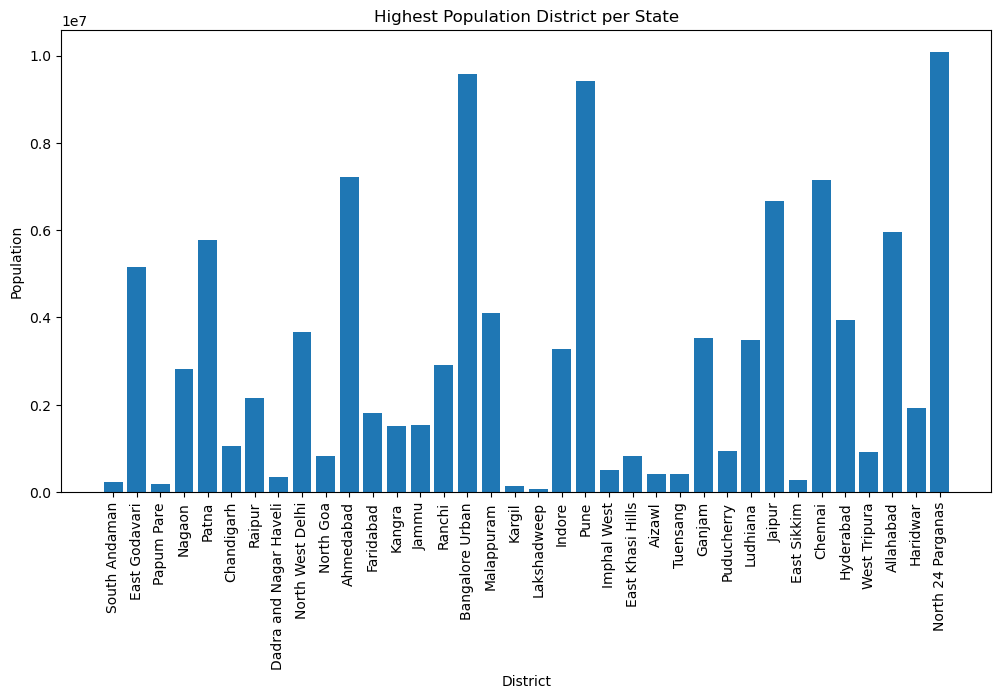

In [26]:
plt.figure(figsize=(12,6))

plt.bar(
    top_district_population["District"],
    top_district_population["Population"]
)

plt.xticks(rotation=90)

plt.title("Highest Population District per State")

plt.xlabel("District")

plt.ylabel("Population")

plt.show()

### Interpretation

The chart shows the most populated district in each state.


## Task 2.5 Average Transaction Value by State

Average Transaction Value (ATV) indicates the typical size of transactions occurring in each state.

In [27]:
avg_atv = state_txn_users.groupby("State")["ATV (INR)"].mean().reset_index()

avg_atv

,State,ATV (INR)
0,Andaman & Nicobar Islands,3159.266422
1,Andhra Pradesh,1748.091476
2,Arunachal Pradesh,2638.323985
3,Assam,2008.495656
4,Bihar,2023.316978
5,Chandigarh,2113.797075
6,Chhattisgarh,1650.818617
7,Dadra & Nagar Haveli and Daman & Diu,1487.395599
8,Delhi,1589.839307
9,Goa,1895.258549


In [32]:
highest_atv = avg_atv.sort_values(by="ATV (INR)",ascending=False).head(5)

highest_atv

# Top 5 states with highest ATV

,State,ATV (INR)
17,Ladakh,3408.222984
0,Andaman & Nicobar Islands,3159.266422
23,Mizoram,2927.517802
18,Lakshadweep,2776.118701
2,Arunachal Pradesh,2638.323985


In [34]:
lowest_atv = avg_atv.sort_values(by="ATV (INR)").head(5)

lowest_atv


,State,ATV (INR)
35,West Bengal,1373.600590
25,Odisha,1428.137367
7,Dadra & Nagar Haveli and Daman & Diu,1487.395599
20,Maharashtra,1516.361820
15,Karnataka,1517.392249


### Interpretation

States with higher ATV values indicate larger financial transactions, which may reflect stronger economic activity or higher-value payments.

## Task 2.6 App Usage Trends


In [35]:
app_usage = state_txn_users.groupby(["Year","Quarter"])["App Opens"].sum().reset_index()

app_usage

,Year,Quarter,App Opens
0,2018,1,0
1,2018,2,0
2,2018,3,0
3,2018,4,0
4,2019,1,0
5,2019,2,920409531
6,2019,3,3448355858
7,2019,4,4301061532
8,2020,1,4768934587
9,2020,2,4357622260


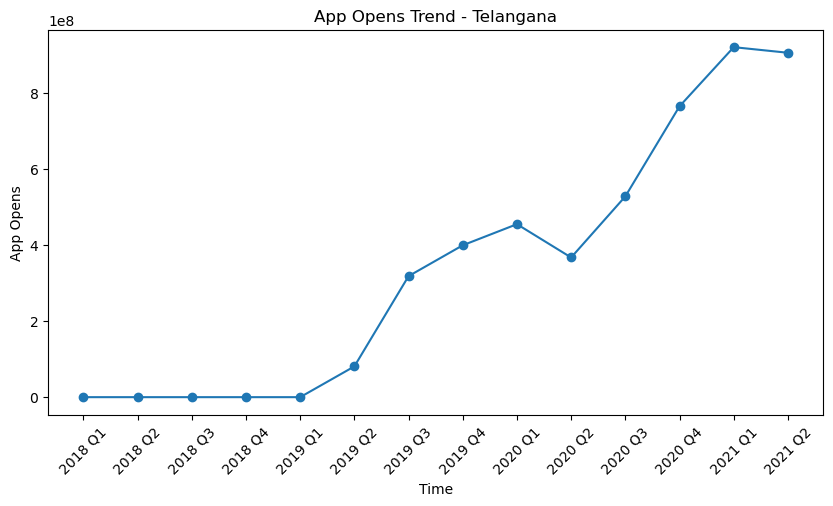

In [36]:
state_selected = "Telangana"

state_app_usage = state_txn_users[state_txn_users["State"] == state_selected]

usage_trend = state_app_usage.groupby(["Year","Quarter"])["App Opens"].sum().reset_index()

usage_trend["Time"] = usage_trend["Year"].astype(str) + " Q" + usage_trend["Quarter"].astype(str)

plt.figure(figsize=(10,5))

plt.plot(usage_trend["Time"], usage_trend["App Opens"], marker="o")

plt.xticks(rotation=45)

plt.title("App Opens Trend - Telangana")

plt.xlabel("Time")

plt.ylabel("App Opens")

plt.show()

### Interpretation

The trend line shows how frequently users interact with the PhonePe application over time.


## Task 2.7 Distribution of Transaction Types


In [41]:
# Find latest year
latest_year = state_txn_split["Year"].max()

# Find latest quarter inside that year
latest_quarter = state_txn_split[state_txn_split["Year"] == latest_year]["Quarter"].max()

# Filter data
recent_data = state_txn_split[
    (state_txn_split["Year"] == latest_year) &
    (state_txn_split["Quarter"] == latest_quarter)
]

# Group data
txn_distribution = recent_data.groupby("Transaction Type")["Transactions"].sum()

print(txn_distribution)

Transaction Type
Financial Services             3397356
Merchant payments           1499624295
Others                         9061701
Peer-to-peer payments       1744265068
Recharge & bill payments     685022045
Name: Transactions, dtype: int64


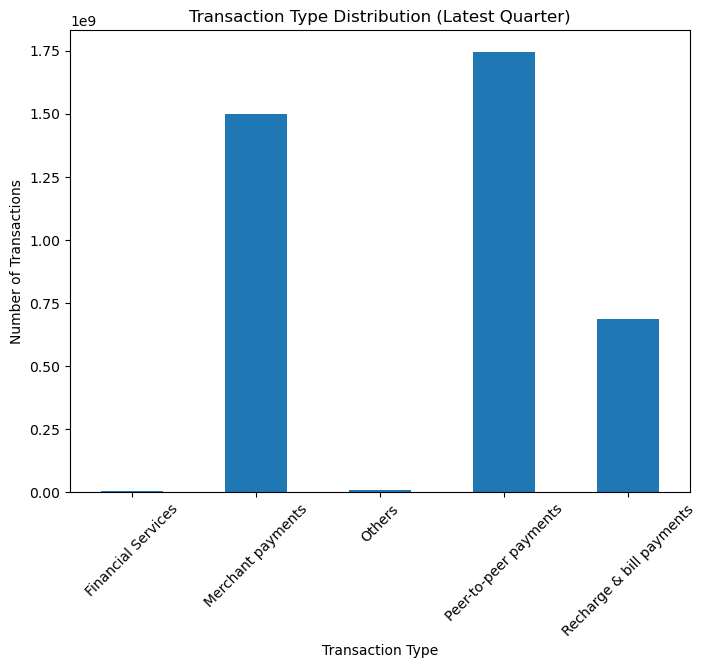

In [42]:
plt.figure(figsize=(8,6))

txn_distribution.plot(kind="bar")

plt.title("Transaction Type Distribution (Latest Quarter)")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

## Task 2.8 Unique District-Code Mapping

Here we identify unique mappings between district names and district codes.

In [43]:
district_mapping = district_txn_users[["District","Code"]].drop_duplicates()

district_mapping

,District,Code
0,Nicobars,AN01
1,North And Middle Andaman,AN02
2,South Andaman,AN03
42,Anantapur,AP01
43,Chittoor,AP02
44,East Godavari,AP03
45,Guntur,AP04
46,Krishna,AP05
47,Kurnool,AP06
48,Prakasam,AP07


In [44]:
district_mapping.to_csv("district_code_mapping.csv", index=False)

### Interpretation
A clean mapping between district names and district codes was created
and exported as a CSV file for easier reference and data integration.

## Task 2 Summary

During the Exploratory Data Analysis stage, we discovered several insights:

• Specific smartphone brands are widely used across states.  

• App usage trends indicate growing engagement over time.

These insights help understand the digital payment ecosystem in India and prepare the data for deeper analysis in subsequent tasks.

# Task 3: Data Quality Checks

In this section, we validate the consistency of the dataset by comparing aggregated district-level data with the corresponding state-level data.

The objective is to ensure that:

• District level totals match state level totals  
• There are no discrepancies in transactions, amounts, or registered users  

This step is essential in real-world analytics because data often originates from multiple sources.

## Task 3.1 Validate State and District Data Consistency


In [47]:
district_state_agg = district_txn_users.groupby("State")[[
    "Transactions",
    "Amount (INR)",
    "Registered Users"
]].sum().reset_index()

district_state_agg.head()

,State,Transactions,Amount (INR),Registered Users
0,Andaman & Nicobar Islands,1223565,3.641818e+09,408396
1,Andhra Pradesh,1781091169,3.860292e+12,158007957
2,Arunachal Pradesh,8043799,2.225183e+10,1862214
3,Assam,123577981,2.814087e+11,26860751
4,Bihar,713643889,1.639579e+12,115284760


The district-level dataset is grouped by state and aggregated to calculate:

• Total transactions  
• Total transaction amount  
• Total registered users

In [48]:
state_level_agg = state_txn_users.groupby("State")[[
    "Transactions",
    "Amount (INR)",
    "Registered Users"
]].sum().reset_index()

state_level_agg.head()

,State,Transactions,Amount (INR),Registered Users
0,Andaman & Nicobar Islands,1223565,3.641818e+09,408396
1,Andhra Pradesh,1781091169,3.187847e+12,158007957
2,Arunachal Pradesh,8043799,2.225183e+10,1862214
3,Assam,123577981,2.814087e+11,26860751
4,Bihar,713643889,1.639579e+12,115284760


In [49]:
comparison = pd.merge(
    state_level_agg,
    district_state_agg,
    on="State",
    suffixes=("_State","_District")
)

comparison.head()

,State,Transactions_State,Amount (INR)_State,Registered Users_State,Transactions_District,Amount (INR)_District,Registered Users_District
0,Andaman & Nicobar Islands,1223565,3.641818e+09,408396,1223565,3.641818e+09,408396
1,Andhra Pradesh,1781091169,3.187847e+12,158007957,1781091169,3.860292e+12,158007957
2,Arunachal Pradesh,8043799,2.225183e+10,1862214,8043799,2.225183e+10,1862214
3,Assam,123577981,2.814087e+11,26860751,123577981,2.814087e+11,26860751
4,Bihar,713643889,1.639579e+12,115284760,713643889,1.639579e+12,115284760


In [50]:
discrepancies = comparison[
    (comparison["Transactions_State"] != comparison["Transactions_District"]) |
    (comparison["Amount (INR)_State"] != comparison["Amount (INR)_District"]) |
    (comparison["Registered Users_State"] != comparison["Registered Users_District"])
]

discrepancies

,State,Transactions_State,Amount (INR)_State,Registered Users_State,Transactions_District,Amount (INR)_District,Registered Users_District
0,Andaman & Nicobar Islands,1223565,3.641818e+09,408396,1223565,3.641818e+09,408396
1,Andhra Pradesh,1781091169,3.187847e+12,158007957,1781091169,3.860292e+12,158007957
2,Arunachal Pradesh,8043799,2.225183e+10,1862214,8043799,2.225183e+10,1862214
3,Assam,123577981,2.814087e+11,26860751,123577981,2.814087e+11,26860751
4,Bihar,713643889,1.639579e+12,115284760,713643889,1.639579e+12,115284760
5,Chandigarh,25516542,5.371208e+10,3801466,25516542,5.371208e+10,3801466
6,Chhattisgarh,241908549,4.156353e+11,37448388,241908549,4.156353e+11,37448388
7,Dadra & Nagar Haveli and Daman & Diu,12462185,1.865878e+10,2701112,12462185,1.865878e+10,2701112
8,Delhi,1011031124,1.649942e+12,95374654,1011031124,1.649942e+12,95374654
9,Goa,24481604,4.427187e+10,4755320,24481604,4.427187e+10,4755320


### Interpretation

If the discrepancies table is empty, it indicates that the district-level totals perfectly match the state-level totals.

If differences exist, it suggests potential issues such as:

• Missing district records  
• Aggregation inconsistencies  
• Data synchronization problems

Such validation checks are commonly performed in real-world data pipelines.

# Task 4: Data Merging and Advanced Analysis

In this section, we combine multiple datasets to perform deeper analysis.

The analysis includes:

• Ratio of registered users to population  
• Correlation between population density and transaction volume  
• Average transaction amount per user  
• Device brand usage ratios

## Task 4.1 User to Population Ratio

We merge demographic data with state-level user data to calculate the ratio of registered users to the population.

In [52]:
state_population = district_demographics.groupby("State")["Population"].sum().reset_index()

state_population.head()

,State,Population
0,Andaman & Nicobar Islands,380581
1,Andhra Pradesh,49378776
2,Arunachal Pradesh,1606047
3,Assam,34461385
4,Bihar,103817951


In [53]:
state_users = state_txn_users.groupby("State")["Registered Users"].max().reset_index()

state_user_population = pd.merge(
    state_users,
    state_population,
    on="State"
)

state_user_population.head()

,State,Registered Users,Population
0,Andaman & Nicobar Islands,62095,380581
1,Andhra Pradesh,19620905,49378776
2,Arunachal Pradesh,270572,1606047
3,Assam,3617056,34461385
4,Bihar,14972134,103817951


In [54]:
state_user_population["User_Population_Ratio"] = (
    state_user_population["Registered Users"] /
    state_user_population["Population"]
)

state_user_population

,State,Registered Users,Population,User_Population_Ratio
0,Andaman & Nicobar Islands,62095,380581,0.163158
1,Andhra Pradesh,19620905,49378776,0.397355
2,Arunachal Pradesh,270572,1606047,0.168471
3,Assam,3617056,34461385,0.104960
4,Bihar,14972134,103817951,0.144215
5,Chandigarh,448572,1055450,0.425005
6,Chhattisgarh,4837055,25867958,0.186990
7,Dadra & Nagar Haveli and Daman & Diu,344994,586956,0.587768
8,Delhi,11182699,16787941,0.666115
9,Goa,609106,1457723,0.417848


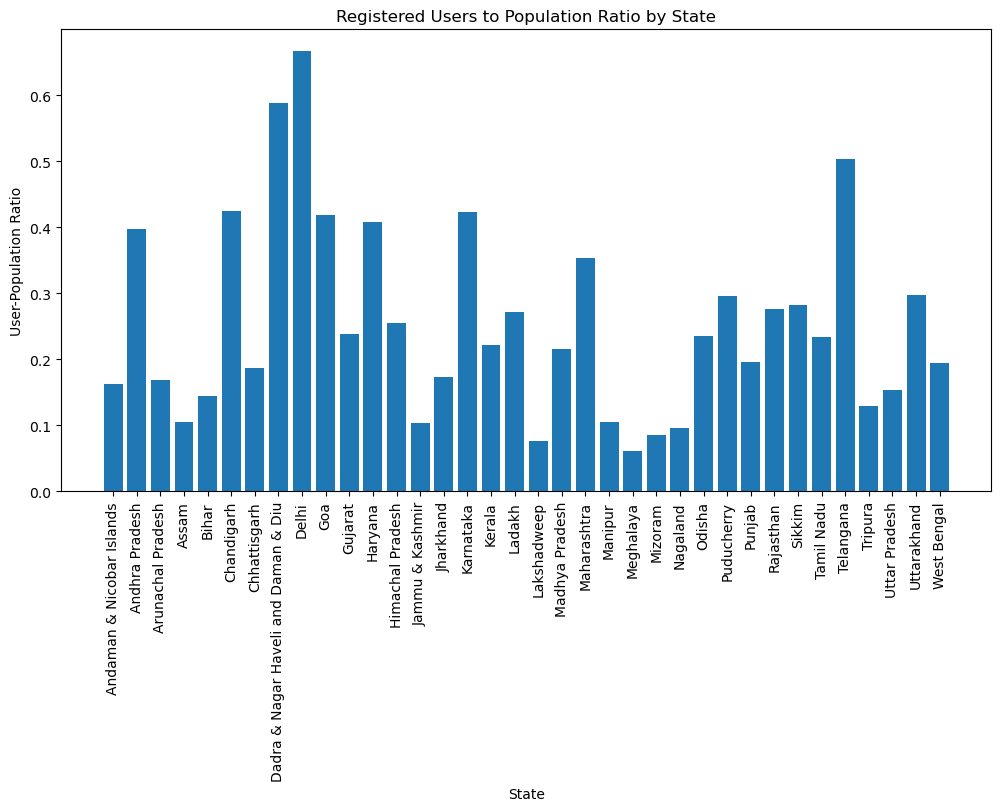

In [55]:
plt.figure(figsize=(12,6))

plt.bar(
    state_user_population["State"],
    state_user_population["User_Population_Ratio"]
)

plt.xticks(rotation=90)

plt.title("Registered Users to Population Ratio by State")

plt.xlabel("State")

plt.ylabel("User-Population Ratio")

plt.show()

States with higher user-population ratios indicate stronger adoption of digital payment platforms.

Lower ratios may suggest opportunities for increased digital payment penetration.

## Task 4.2 Population Density vs Transaction Volume

This analysis investigates whether districts with higher population density also exhibit higher transaction volumes.

In [57]:
district_merge = pd.merge(
    district_txn_users,
    district_demographics,
    on=["State","District","Code"]
)

district_merge.head()

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Headquarters,Population,Area (sq km),Density,Alternate Name
0,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0,Port Blair,238142,2672.0,89,South Andaman
1,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0,Port Blair,238142,2672.0,89,South Andaman
2,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0,Port Blair,238142,2672.0,89,South Andaman
3,Andaman & Nicobar Islands,2018,4,South Andaman,AN03,20136,7.541184e+07,3745.125189,13133,0,Port Blair,238142,2672.0,89,South Andaman
4,Andaman & Nicobar Islands,2019,1,South Andaman,AN03,25683,8.550197e+07,3329.127142,15961,0,Port Blair,238142,2672.0,89,South Andaman


In [58]:
correlation = district_merge["Density"].corr(district_merge["Transactions"])

print("Correlation between Population Density and Transactions:", correlation)

Correlation between Population Density and Transactions: 0.3077041087559286


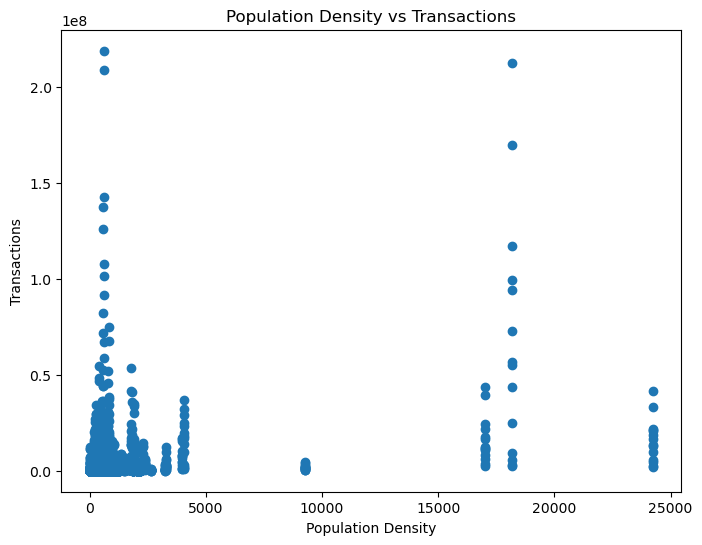

In [59]:
plt.figure(figsize=(8,6))

plt.scatter(
    district_merge["Density"],
    district_merge["Transactions"]
)

plt.title("Population Density vs Transactions")

plt.xlabel("Population Density")

plt.ylabel("Transactions")

plt.show()

The scatter plot helps visualize the relationship between population density and transaction activity.

A positive correlation would indicate that densely populated districts tend to generate more digital payment transactions.

## Task 4.3 Average Transaction Amount per User

This metric helps evaluate spending behavior of users across states.

In [61]:
state_summary = state_txn_users.groupby("State")[[
    "Amount (INR)",
    "Registered Users"
]].sum().reset_index()

state_summary["Avg_Amount_Per_User"] = (
    state_summary["Amount (INR)"] /
    state_summary["Registered Users"]
)

state_summary

,State,Amount (INR),Registered Users,Avg_Amount_Per_User
0,Andaman & Nicobar Islands,3.641818e+09,408396,8917.369075
1,Andhra Pradesh,3.187847e+12,158007957,20175.233763
2,Arunachal Pradesh,2.225183e+10,1862214,11949.126662
3,Assam,2.814087e+11,26860751,10476.576498
4,Bihar,1.639579e+12,115284760,14221.991933
5,Chandigarh,5.371208e+10,3801466,14129.308175
6,Chhattisgarh,4.156353e+11,37448388,11098.884128
7,Dadra & Nagar Haveli and Daman & Diu,1.865878e+10,2701112,6907.815954
8,Delhi,1.649942e+12,95374654,17299.587909
9,Goa,4.427187e+10,4755320,9309.966756


In [62]:
top5_spending_states = state_summary.sort_values(
    by="Avg_Amount_Per_User",
    ascending=False
).head(5)

top5_spending_states

,State,Amount (INR),Registered Users,Avg_Amount_Per_User
31,Telangana,4.574246e+12,149224214,30653.509622
15,Karnataka,4.361396e+12,203098564,21474.282206
1,Andhra Pradesh,3.187847e+12,158007957,20175.233763
28,Rajasthan,2.625584e+12,149770064,17530.768707
8,Delhi,1.649942e+12,95374654,17299.587909


In [63]:
bottom5_spending_states = state_summary.sort_values(
    by="Avg_Amount_Per_User"
).head(5)

bottom5_spending_states

,State,Amount (INR),Registered Users,Avg_Amount_Per_User
18,Lakshadweep,1.921587e+08,34223,5614.898889
32,Tripura,2.097051e+10,3661575,5727.184275
7,Dadra & Nagar Haveli and Daman & Diu,1.865878e+10,2701112,6907.815954
16,Kerala,3.729599e+11,51267042,7274.846690
12,Himachal Pradesh,9.786546e+10,13373980,7317.601442


## Task 4.4 Device Brand Usage Ratio

We analyze the share of different device brands used by PhonePe users in each state.

In [64]:
device_merge = pd.merge(
    state_device_data,
    state_users,
    on="State"
)

device_merge.head()

,State,Year,Quarter,Brand,Registered Users_x,Percentage,Registered Users_y
0,Andaman & Nicobar Islands,2018,1,Xiaomi,1665,0.247033,62095
1,Andaman & Nicobar Islands,2018,1,Samsung,1445,0.214392,62095
2,Andaman & Nicobar Islands,2018,1,Vivo,982,0.145697,62095
3,Andaman & Nicobar Islands,2018,1,Oppo,501,0.074332,62095
4,Andaman & Nicobar Islands,2018,1,OnePlus,332,0.049258,62095


In [65]:
device_merge["Brand_Usage_Ratio"] = (
    device_merge["Registered Users_x"] /
    device_merge["Registered Users_y"]
)

device_merge[["State","Brand","Brand_Usage_Ratio"]]

,State,Brand,Brand_Usage_Ratio
0,Andaman & Nicobar Islands,Xiaomi,0.026814
1,Andaman & Nicobar Islands,Samsung,0.023271
2,Andaman & Nicobar Islands,Vivo,0.015814
3,Andaman & Nicobar Islands,Oppo,0.008068
4,Andaman & Nicobar Islands,OnePlus,0.005347
5,Andaman & Nicobar Islands,Realme,0.005089
6,Andaman & Nicobar Islands,Apple,0.003688
7,Andaman & Nicobar Islands,Motorola,0.003640
8,Andaman & Nicobar Islands,Lenovo,0.003253
9,Andaman & Nicobar Islands,Huawei,0.002544


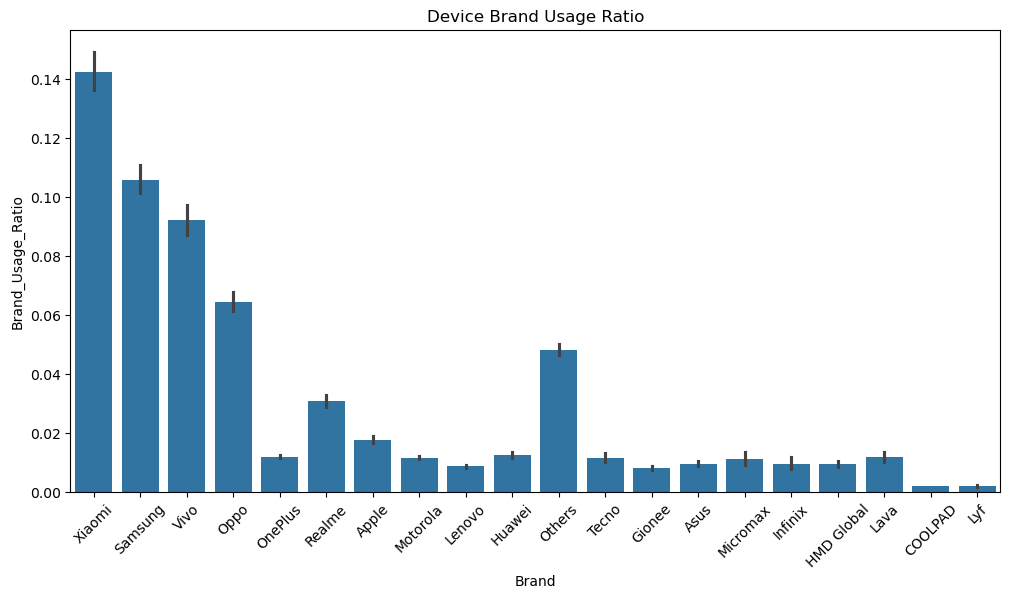

In [66]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=device_merge,
    x="Brand",
    y="Brand_Usage_Ratio"
)

plt.xticks(rotation=45)

plt.title("Device Brand Usage Ratio")

plt.show()

## Task 4 Summary

This section combined multiple datasets to generate deeper insights.

These insights can help digital payment platforms optimize their market strategies.

# Task 5: Data Visualization

Data visualization helps transform raw data into meaningful graphical insights.

In this section we create visualizations to understand:

• Transaction trends over time  
• Distribution of transaction types  
• Population density across districts

## Task 5.1 Transaction Trend for a Selected State

We analyze how the number of transactions and transaction amount change over time for a specific state.

In [67]:
selected_state = "Telangana"

state_data = state_txn_users[state_txn_users["State"] == selected_state]

trend_data = state_data.groupby(["Year","Quarter"])[
    ["Transactions","Amount (INR)"]
].sum().reset_index()

trend_data["Time"] = trend_data["Year"].astype(str) + " Q" + trend_data["Quarter"].astype(str)

trend_data

,Year,Quarter,Transactions,Amount (INR),Time
0,2018,1,8522766,1.330820e+10,2018 Q1
1,2018,2,10764670,2.301720e+10,2018 Q2
2,2018,3,19332703,3.203009e+10,2018 Q3
3,2018,4,28921154,4.950909e+10,2018 Q4
4,2019,1,65290702,9.552326e+10,2019 Q1
5,2019,2,89610379,1.556764e+11,2019 Q2
6,2019,3,121495376,2.019300e+11,2019 Q3
7,2019,4,163572258,2.807468e+11,2019 Q4
8,2020,1,199409525,3.713438e+11,2020 Q1
9,2020,2,152055143,3.215318e+11,2020 Q2


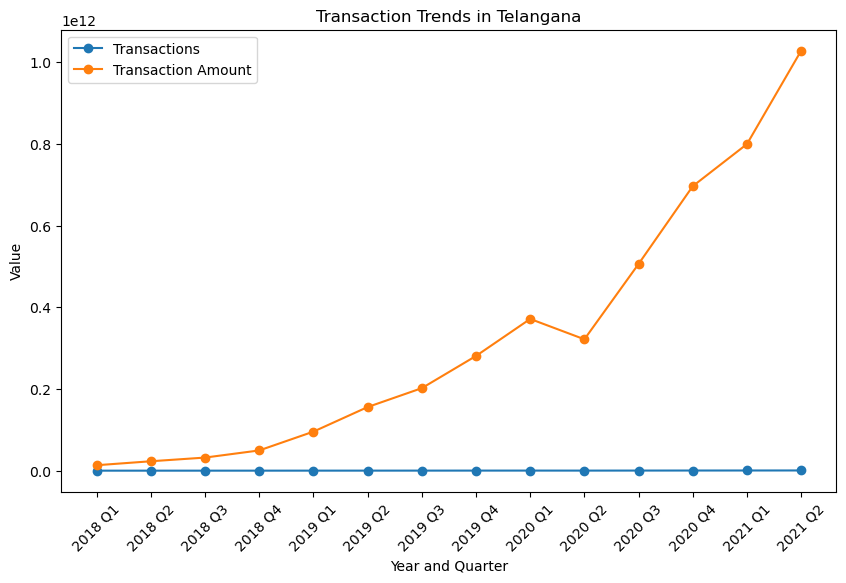

In [68]:
plt.figure(figsize=(10,6))

plt.plot(trend_data["Time"], trend_data["Transactions"], marker='o', label="Transactions")

plt.plot(trend_data["Time"], trend_data["Amount (INR)"], marker='o', label="Transaction Amount")

plt.xticks(rotation=45)

plt.title("Transaction Trends in Telangana")

plt.xlabel("Year and Quarter")

plt.ylabel("Value")

plt.legend()

plt.show()

### Interpretation

The visualization highlights the growth pattern of digital transactions in the selected state over time.

Increasing trends indicate growing digital payment adoption and higher transaction volumes.

## Task 5.2 Distribution of Transaction Types

A pie chart is created to show the proportion of each transaction category in the selected state and quarter.

In [69]:
selected_year = latest_year
selected_quarter = latest_quarter

txn_data = state_txn_split[
    (state_txn_split["State"] == selected_state) &
    (state_txn_split["Year"] == selected_year) &
    (state_txn_split["Quarter"] == selected_quarter)
]

txn_summary = txn_data.groupby("Transaction Type")["Transactions"].sum()

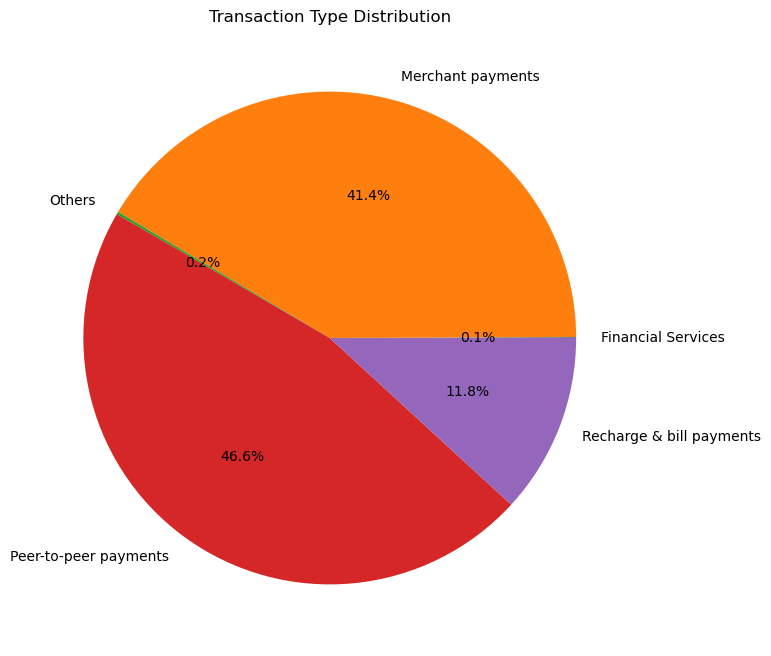

In [70]:
plt.figure(figsize=(8,8))

plt.pie(
    txn_summary,
    labels=txn_summary.index,
    autopct='%1.1f%%'
)

plt.title("Transaction Type Distribution")

plt.show()

### Interpretation

The pie chart shows the share of each transaction category.

Peer-to-peer payments and bill payments typically dominate digital payment ecosystems.

## Task 5.3 Population Density Visualization

We visualize population density across districts within a selected state.

In [72]:
density_data = district_demographics[
    district_demographics["State"] == selected_state
]

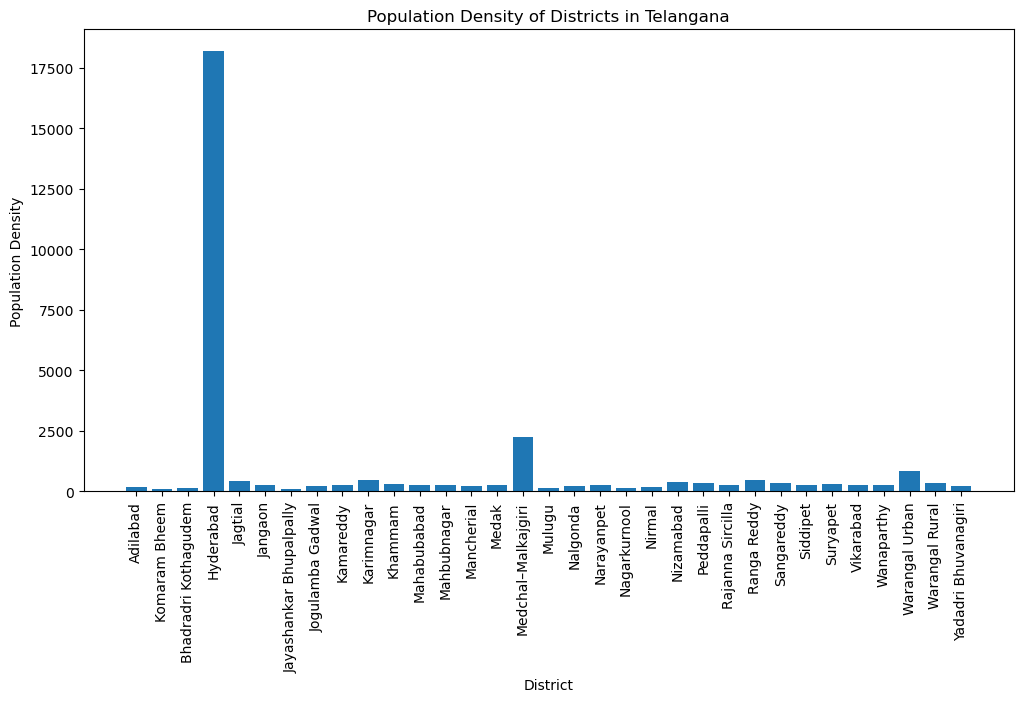

In [73]:
plt.figure(figsize=(12,6))

plt.bar(
    density_data["District"],
    density_data["Density"]
)

plt.xticks(rotation=90)

plt.title("Population Density of Districts in Telangana")

plt.xlabel("District")

plt.ylabel("Population Density")

plt.show()

### Interpretation

The bar chart illustrates population density differences across districts.

Higher density districts may have greater digital payment activity due to urbanization.

## Task 6.1 Trends and Patterns in Transaction Data

From the analysis performed in previous sections, several trends can be observed:

1. Digital transaction volumes have steadily increased across most states over time.
2. Urbanized states tend to exhibit higher transaction volumes.
3. Peer-to-peer payments are the most dominant transaction category.
4. Smartphone penetration plays a crucial role in digital payment adoption.

These patterns highlight the growing importance of mobile-based digital payment platforms in India.

## Task 6.2 Demographic and Transaction Correlation

The analysis of population density and transaction volumes indicates that:

• Districts with higher population density generally exhibit higher transaction activity.

• Urban districts tend to have greater digital payment adoption.

• Rural regions may have lower transaction volumes due to limited digital infrastructure.

This demonstrates that demographic characteristics play a significant role in digital payment adoption.

## Task 6.3 Key Insights and Recommendations

### Key Insights

1. Digital payment adoption is increasing across India.
2. Certain states contribute disproportionately to transaction volume.
3. Population density and urbanization influence transaction behavior.
4. Smartphone usage strongly correlates with digital payment adoption.

### Recommendations

1. Payment platforms should focus on expanding digital infrastructure in rural districts.
2. Partnerships with smartphone manufacturers can increase payment app adoption.
3. Awareness campaigns can help increase digital payment usage in low adoption states.
4. Data-driven targeting can help identify high growth regions for digital payment expansion.

# Final Summary

This case study analyzed PhonePe digital transaction data along with demographic information across states and districts in India.

Key activities performed during the analysis include:

• Data loading and exploration  
• Data quality validation  
• Transaction trend analysis  
• Device usage analysis  
• Demographic correlation analysis  
• Data visualization  

The analysis revealed important patterns in digital payment adoption and highlighted how demographic and technological factors influence transaction behavior.

Overall, the study demonstrates the rapid growth of digital payments in India and identifies opportunities to further expand digital payment adoption.

# Final Project Conclusion
This project analyzed PhonePe digital transaction data across India using Python. The analysis explored transaction growth trends, digital payment adoption across states, device usage patterns, and demographic influences on transactions. By combining transaction, user, and population datasets, I identified key insights such as higher digital adoption in urban regions, strong growth in peer-to-peer transactions, and the influence of smartphone penetration on digital payments.